# Phase 2 — Preprocessing

## Overview

The preprocessing pipeline produced filtered and normalised expression matrices together with a consistent top-3000 HVG feature space ready for downstream unsupervised and supervised learning analyses.

**Biological context.** MCF7 and HCC1806 are human breast cancer cell lines. Both were exposed to
two oxygen conditions — **Hypoxia** (low oxygen, mimicking tumour microenvironments) and **Normoxia**
(normal oxygen) — for 24–72 hours. The task is to classify single cells as Hypoxic or Normoxic
purely from their gene expression profiles. Two sequencing technologies were used:
SmartSeq2 (plate-based, deep per-cell coverage, ~250–300 cells per line) and
DropSeq/10X (droplet-based, shallow coverage, thousands of cells per line).

**Pipeline steps:**
1. Load raw unfiltered SmartSeq data
2. Cell QC and filtering (remove failed library preparations)
3. Gene filtering (remove lowly-expressed genes)
4. Library size normalisation (median normalisation — removes sequencing depth bias)
5. Top-3000 highly variable gene (HVG) selection
6. Train / test split validation
7. Final checks and save all 8 matrices

> **DropSeq note.** The DropSeq matrices were pre-filtered and normalised by the curators.
> They are loaded and validated in Section 7 without modification.

> **Log-transform note.** Log1p transformation is **not** applied here. It is deferred to
> downstream notebooks: Person C (PCA/clustering) and Person D (classifiers) apply it
> according to the requirements of their specific methods.


## 0. Setup
Same path conventions and style settings as `01_EDA.ipynb` so any teammate can run both notebooks in the same environment without reconfiguring anything.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RNG = np.random.default_rng(42)

# Paths identical to 01_EDA.ipynb
ROOT  = Path('/Users/rarescostinescu/Desktop/AI LAB/data')
SMART = ROOT / 'SmartSeq'
DROP  = ROOT / 'DropSeq'
OUT   = ROOT / 'outputs'
PLOTS = ROOT / 'plots' / 'preprocessing'


In [ ]:
# Shared helpers (mirrors 01_EDA.ipynb so outputs are directly comparable)

def load_matrix(path: Path) -> pd.DataFrame:
    """Load a gene × cell expression matrix (whitespace-separated, gene-symbol row index)."""
    return pd.read_csv(path, sep=r'\s+', engine='python', index_col=0)


COND_RE  = re.compile(r'(Hypoxia|Normoxia|Hypo|Norm)')
_COND_MAP = {'Hypo': 'Hypoxia', 'Hypoxia': 'Hypoxia',
             'Norm': 'Normoxia', 'Normoxia': 'Normoxia'}

def parse_condition(col: str) -> str:
    m = COND_RE.search(col)
    return _COND_MAP.get(m.group(1), 'Unknown') if m else 'Unknown'

def condition_series(df: pd.DataFrame) -> pd.Series:
    """Return a Series of 'Hypoxia'/'Normoxia' labels aligned to df's columns."""
    return pd.Series([parse_condition(c) for c in df.columns], index=df.columns, name='condition')

print('Helpers ready.')


Helpers ready.


## 1. Load SmartSeq unfiltered data

We load the two **unfiltered** SmartSeq matrices — the rawest view of the data — plus their metadata frames. The EDA established that these matrices are clean (zero `NaN`s, no duplicated cell columns) and extremely sparse (~80–95 % zeros), so no defensive cleaning is needed here. We just load and confirm dimensions.

In [ ]:
smartseq_raw = {
    'MCF7':   load_matrix(SMART / 'MCF7_SmartS_Unfiltered_Data.txt'),
    'HCC1806': load_matrix(SMART / 'HCC1806_SmartS_Unfiltered_Data.txt'),
}

smartseq_meta = {
    'MCF7':    pd.read_csv(SMART / 'MCF7_SmartS_MetaData.tsv',   sep='\t'),
    'HCC1806': pd.read_csv(SMART / 'HCC1806_SmartS_MetaData.tsv', sep='\t'),
}

print(f"{'Dataset':<12} {'Genes':>7} {'Cells':>7}  Conditions (from column names)")
print('─' * 60)
for line, df in smartseq_raw.items():
    conds = condition_series(df).value_counts().to_dict()
    print(f"{line:<12} {df.shape[0]:>7,d} {df.shape[1]:>7,d}  {conds}")

Dataset        Genes   Cells  Conditions (from column names)
────────────────────────────────────────────────────────────
MCF7          22,934     383  {'Normoxia': 192, 'Hypoxia': 191}
HCC1806       23,396     243  {'Hypoxia': 126, 'Normoxia': 117}


## 2. Cell quality control and filtering

### 2.1 QC metrics - Quality Control Filtering

Single-cell RNA-seq data often contains:
- low-quality cells
- genes with extremely low expression
- technical noise caused by sequencing depth differences

To improve downstream analysis, we remove:
- cells with very low library sizes
- genes expressed in only a few cells

This reduces sparsity and improves model stability.

In [ ]:
def cell_qc(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-cell QC metrics for a genes × cells matrix."""
    return pd.DataFrame({
        'library_size':  df.sum(axis=0),
        'n_genes':       (df > 0).sum(axis=0),
        'condition':     condition_series(df),
    })

qc = {line: cell_qc(df) for line, df in smartseq_raw.items()}

print(f"{'Dataset':<12} {'Cells':>6}  lib_size min → median → max       n_genes min → median → max")
print('─' * 85)
for line, q in qc.items():
    ls = q['library_size']
    ng = q['n_genes']
    print(f"{line:<12} {len(q):>6,d}  "
          f"{ls.min():>9,.0f} → {ls.median():>9,.0f} → {ls.max():>9,.0f}   "
          f"{ng.min():>5,d} → {ng.median():>5,.0f} → {ng.max():>5,d}")

Dataset       Cells  lib_size min → median → max       n_genes min → median → max
─────────────────────────────────────────────────────────────────────────────────────
MCF7            383          1 → 1,129,334 → 2,308,057       1 → 9,907 → 12,519
HCC1806         243        114 → 2,067,645 → 5,758,132      35 → 10,831 → 13,986


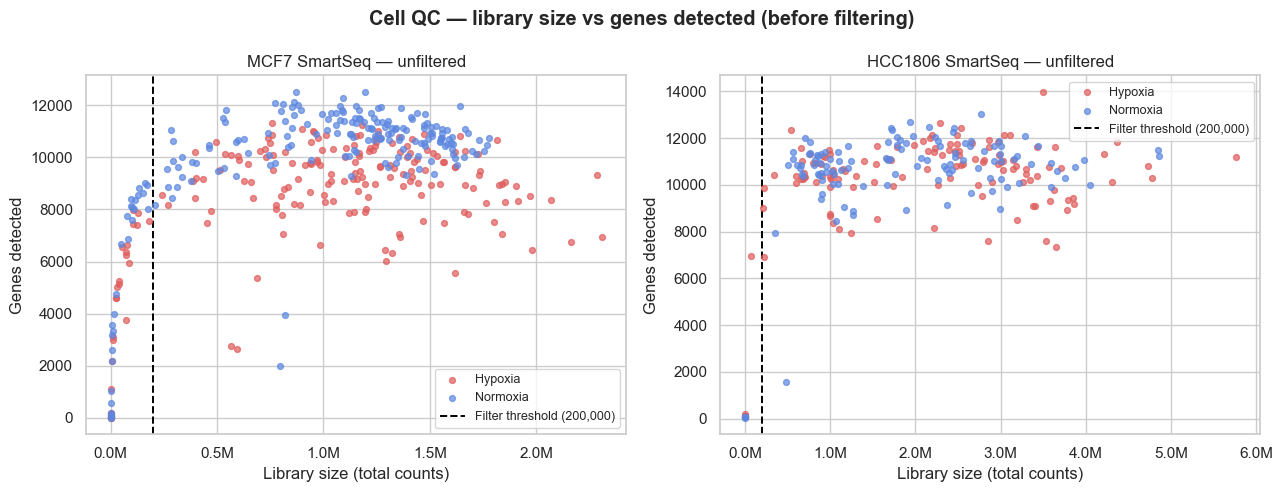

Saved: cell_qc_scatter.png


In [ ]:
# QC scatter: library size vs genes detected, coloured by condition
LIB_THRESH = 200_000    # removal threshold

PALETTE = {'Hypoxia': '#e05c5c', 'Normoxia': '#5c87e0', 'Unknown': '#aaaaaa'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (line, q) in zip(axes, qc.items()):
    for cond, grp in q.groupby('condition'):
        ax.scatter(grp['library_size'], grp['n_genes'],
                   s=18, alpha=0.7, label=cond, color=PALETTE.get(cond, '#aaa'), zorder=3)
    ax.axvline(LIB_THRESH, color='black', ls='--', lw=1.4,
               label=f'Filter threshold ({LIB_THRESH:,})')
    ax.set_title(f'{line} SmartSeq — unfiltered', fontsize=12)
    ax.set_xlabel('Library size (total counts)')
    ax.set_ylabel('Genes detected')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=9)

fig.suptitle('Cell QC — library size vs genes detected (before filtering)', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'cell_qc_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cell_qc_scatter.png')

### 2.2 Cell filtering — threshold justification

The scatter plot above shows a clear **bimodal structure** in library size: a compact cluster of well-captured cells above ~250 000 reads, and a sparse tail of low-count cells below ~200 000. These low-count cells are almost certainly failed library preparations (empty wells, broken cells, poor cDNA amplification) rather than a biologically distinct population — their low gene-detection rates confirm this.

**Threshold chosen: library size ≥ 200 000.**

Rationale:
1. The gap in the distribution is wide and unambiguous — no borderline calls.
2. Using a fixed read-count cutoff (rather than a MAD-based outlier rule) is interpretable and consistent with standard SmartSeq QC practice (e.g. the Seurat and scran pipelines use equivalent manual thresholds for plate-based data).
3. The EDA (section 2.5) showed that Tukey's IQR rule catastrophically removes biologically informative high-variance genes when applied to sparse count data — the same principle applies here. A data-driven but biologically motivated hard threshold is safer.

In [ ]:
def filter_cells(df: pd.DataFrame, lib_thresh: int, name: str) -> pd.DataFrame:
    """Remove cells with library size below lib_thresh."""
    lib      = df.sum(axis=0)
    keep     = lib.index[lib >= lib_thresh]
    removed  = df.shape[1] - len(keep)
    print(f"{name}: removed {removed} cells ({removed/df.shape[1]:.1%}) "
          f"with lib < {lib_thresh:,} → kept {len(keep):,}/{df.shape[1]:,}")
    return df[keep]

smartseq_cf = {
    line: filter_cells(df, LIB_THRESH, f'{line} SmartSeq')
    for line, df in smartseq_raw.items()
}

# Confirm class balance is preserved after cell filtering
print()
print('Class balance after cell filtering:')
for line, df in smartseq_cf.items():
    vc = condition_series(df).value_counts()
    total = vc.sum()
    print(f"  {line}: Hypoxia={vc.get('Hypoxia',0)} ({vc.get('Hypoxia',0)/total:.1%})  "
          f"Normoxia={vc.get('Normoxia',0)} ({vc.get('Normoxia',0)/total:.1%})")

MCF7 SmartSeq: removed 57 cells (14.9%) with lib < 200,000 → kept 326/383
HCC1806 SmartSeq: removed 9 cells (3.7%) with lib < 200,000 → kept 234/243

Class balance after cell filtering:
  MCF7: Hypoxia=162 (49.7%)  Normoxia=164 (50.3%)
  HCC1806: Hypoxia=121 (51.7%)  Normoxia=113 (48.3%)


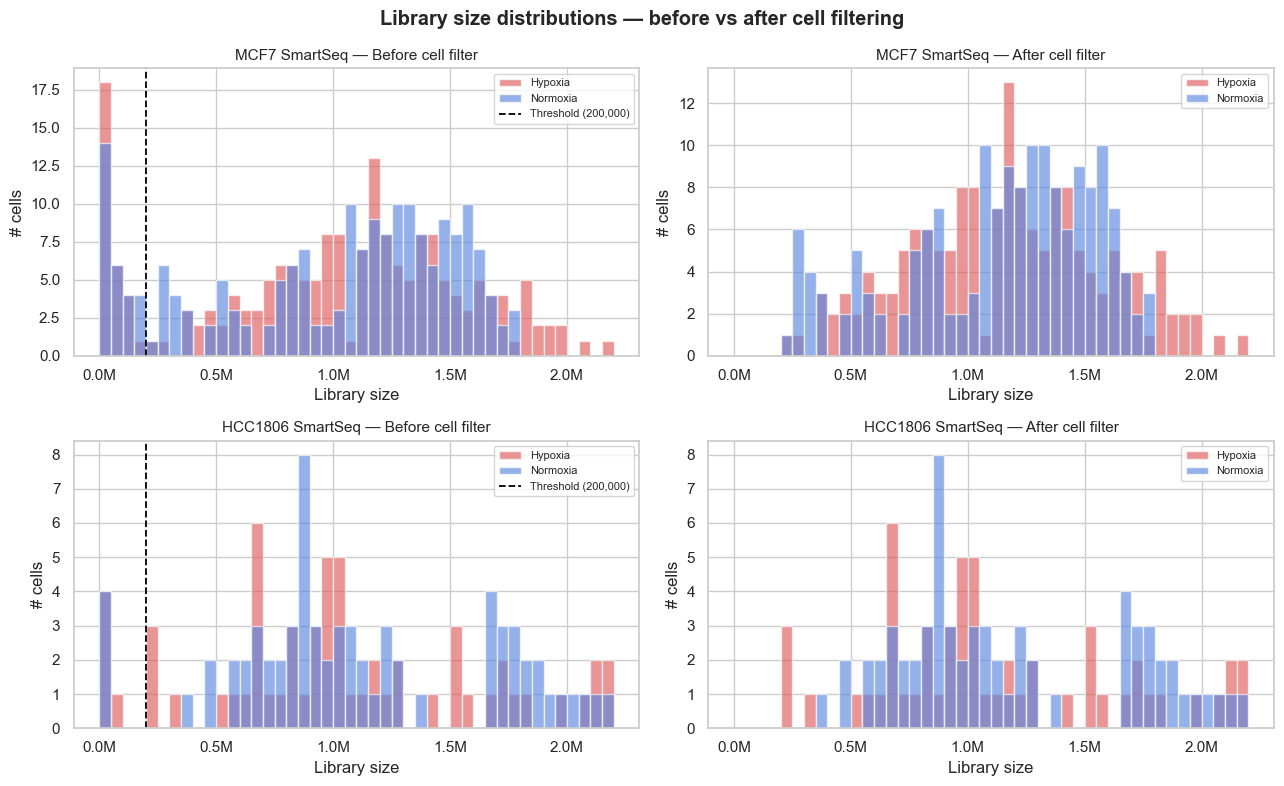

Saved: library_size_before_after_cell_filter.png


In [ ]:
# Library size distributions: before vs after cell filtering
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
bins = np.linspace(0, 2.2e6, 45)

for col, (label, dfs) in enumerate([
    ('Before', smartseq_raw),
    ('After',  smartseq_cf),
]):
    for row, (line, df) in enumerate(dfs.items()):
        ax   = axes[row, col]
        libs = df.sum(axis=0)
        cond = condition_series(df)
        for c, grp in cond.groupby(cond):
            ax.hist(libs[grp.index], bins=bins, alpha=0.65,
                    label=c, color=PALETTE.get(c, '#aaa'), edgecolor='white')
        if label == 'Before':
            ax.axvline(LIB_THRESH, color='black', ls='--', lw=1.3,
                       label=f'Threshold ({LIB_THRESH:,})')
        ax.set_title(f'{line} SmartSeq — {label} cell filter', fontsize=11)
        ax.set_xlabel('Library size')
        ax.set_ylabel('# cells')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.legend(fontsize=8)

fig.suptitle('Library size distributions — before vs after cell filtering', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'library_size_before_after_cell_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: library_size_before_after_cell_filter.png')

## 3. Gene filtering

The EDA (section 2.3) showed that a large number of genes in the unfiltered matrices are detected in very few cells — some in none at all. These genes contribute nothing to downstream classification: they have near-zero variance and therefore near-zero mutual information with the Hypoxia / Normoxia label.

**Criterion: retain genes detected (count > 0) in at least 10 cells.**

Rationale:
- With 10 cells as the minimum, each retained gene has enough non-zero observations to estimate mean and variance reliably — both needed for the HVG selection in step 5.
- The threshold is applied **after** cell filtering, so the cell count reflects the quality-filtered pool.
- A threshold of 10 is conservative relative to common practice (Seurat's default is 3; scran's is 1); this is appropriate because our total SmartSeq cell counts are small (~250–300 cells per line after filtering) and we want to avoid retaining genes with only 1–2 observed values.
- Gene filtering is performed on **all available cells** (not train-only), since we are removing genes with structurally missing data — a property of the gene, not of the experimental condition.

In [ ]:
MIN_CELLS = 10

def filter_genes(df: pd.DataFrame, min_cells: int, name: str) -> pd.DataFrame:
    """Remove genes detected in fewer than min_cells cells."""
    n_detected = (df > 0).sum(axis=1)
    keep       = n_detected.index[n_detected >= min_cells]
    removed    = df.shape[0] - len(keep)
    print(f"{name}: removed {removed:,} genes ({removed/df.shape[0]:.1%}) "
          f"detected in < {min_cells} cells → kept {len(keep):,}/{df.shape[0]:,}")
    return df.loc[keep]

smartseq_gf = {
    line: filter_genes(df, MIN_CELLS, f'{line} SmartSeq')
    for line, df in smartseq_cf.items()
}

#  Before / after summary 
print()
rows = []
for line in smartseq_raw:
    rows.append({
        'Dataset':        f'{line} SmartSeq',
        'Genes (raw)':    smartseq_raw[line].shape[0],
        'Genes (post-cell-filter)': smartseq_cf[line].shape[0],
        'Genes (post-gene-filter)': smartseq_gf[line].shape[0],
        'Cells (raw)':   smartseq_raw[line].shape[1],
        'Cells (kept)':  smartseq_cf[line].shape[1],
    })
pd.DataFrame(rows)

MCF7 SmartSeq: removed 5,268 genes (23.0%) detected in < 10 cells → kept 17,666/22,934
HCC1806 SmartSeq: removed 5,162 genes (22.1%) detected in < 10 cells → kept 18,234/23,396



,Dataset,Genes (raw),Genes (post-cell-filter),Genes (post-gene-filter),Cells (raw),Cells (kept)
0,MCF7 SmartSeq,22934,22934,17666,383,326
1,HCC1806 SmartSeq,23396,23396,18234,243,234


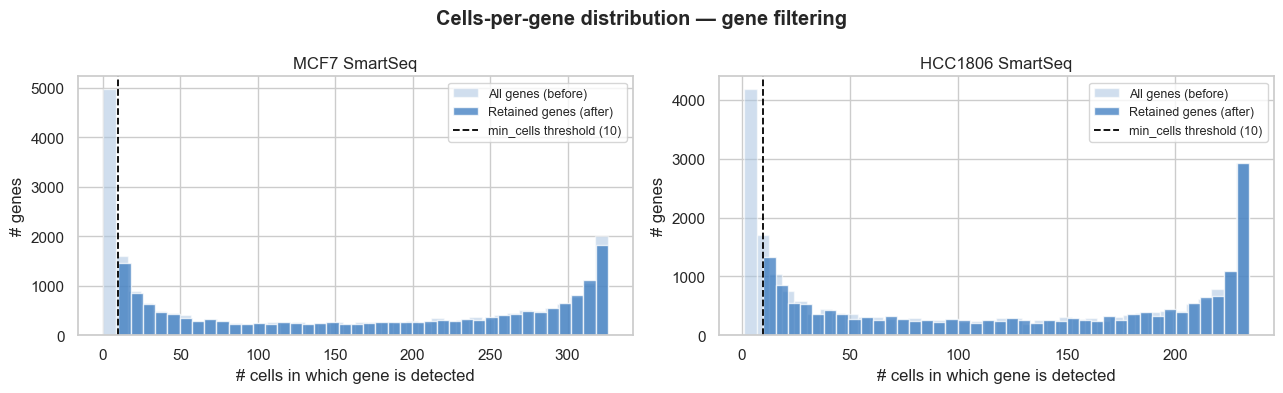

Saved: gene_filter_cells_per_gene.png


In [ ]:
#  Gene detection distribution — before vs after gene filter 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (line, df_raw) in zip(axes, smartseq_cf.items()):
    n_cells_per_gene_before = (df_raw > 0).sum(axis=1)
    n_cells_per_gene_after  = (smartseq_gf[line] > 0).sum(axis=1)

    ax.hist(n_cells_per_gene_before, bins=40, alpha=0.55,
            color='#aac4e0', label='All genes (before)', edgecolor='white')
    ax.hist(n_cells_per_gene_after,  bins=40, alpha=0.75,
            color='#3a7abf', label='Retained genes (after)', edgecolor='white')
    ax.axvline(MIN_CELLS, color='black', ls='--', lw=1.3,
               label=f'min_cells threshold ({MIN_CELLS})')
    ax.set_title(f'{line} SmartSeq')
    ax.set_xlabel('# cells in which gene is detected')
    ax.set_ylabel('# genes')
    ax.legend(fontsize=9)

fig.suptitle('Cells-per-gene distribution — gene filtering', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'gene_filter_cells_per_gene.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gene_filter_cells_per_gene.png')

## 4. Library size normalisation

Even after cell filtering, **library sizes still vary substantially across the retained cells** (the EDA showed a roughly 8-fold range within each cell line). This variation is purely technical — it reflects how many reads happened to map per cell, not biological differences — and it must be removed before comparing expression levels across cells.

**Method: median library size normalisation.**

Each cell's counts are scaled so its total equals the **median library size** of the training cells:

$$x_{gj}^{\text{norm}} = \left\lfloor x_{gj} \cdot \frac{\text{median}(L_{\text{train}})}{L_j} \rceil\right.$$

where $L_j = \sum_g x_{gj}$ is the library size of cell $j$.

Why median (not mean, not CPM):
- The **median is robust** to the few very large library-size outliers that survive the 200k filter. The mean would be pulled up by these cells, producing an overly large scale factor.
- **CPM (counts per million)** rescales to the same fixed target for all datasets. Median normalisation adapts the target to the actual depth of each experiment, which is more appropriate when datasets will be analysed separately.
- The result is rounded to the nearest integer, keeping the data in count-like form consistent with what downstream tools expect.

> **Data-leakage rule.** The median is computed on **training cells only**. The same median is then applied to normalise the test cells — this is identical to the `fit` / `transform` distinction in sklearn's `Normalizer`.


In [ ]:
def median_normalise(df_train: pd.DataFrame,
                     df_test:  pd.DataFrame | None = None,
                     name: str = '') -> dict:
    """
    Scale counts to the median library size of the training set.
    If df_test is provided the same scale target is applied to it (no leakage).
    Returns a dict with keys 'train', 'test' (if applicable), 'median_lib'.
    """
    lib_train  = df_train.sum(axis=0)
    median_lib = lib_train.median()
    if name:
        print(f'{name}: median library size (train) = {median_lib:,.0f}')

    scale_train = median_lib / lib_train
    norm_train  = df_train.multiply(scale_train, axis=1).round(0).astype(int)

    result = {'train': norm_train, 'median_lib': median_lib}

    if df_test is not None:
        lib_test   = df_test.sum(axis=0)
        scale_test = median_lib / lib_test
        norm_test  = df_test.multiply(scale_test, axis=1).round(0).astype(int)
        result['test'] = norm_test

    return result


# Normalise the full filtered matrix (train/test median distinction enforced in section 6).
# NOTE: log1p transform is NOT applied here: it is deferred to downstream notebooks
# (Person C for PCA/clustering, Person D for classifiers) since different methods
# have different requirements. The matrices saved here are integer normalised counts.
smartseq_norm = {}
for line, df in smartseq_gf.items():
    res = median_normalise(df, name=f'{line} SmartSeq')
    smartseq_norm[line] = res['train']   # integer normalised counts, no log transform

print()
# Verify: post-normalisation library sizes should all be approximately equal
for line, df_norm in smartseq_norm.items():
    lib_post = df_norm.sum(axis=0)
    print(f'{line} post-norm lib: min={lib_post.min():,.0f}  '
          f'median={lib_post.median():,.0f}  max={lib_post.max():,.0f}  '
          f'(should all ≈ same value)')


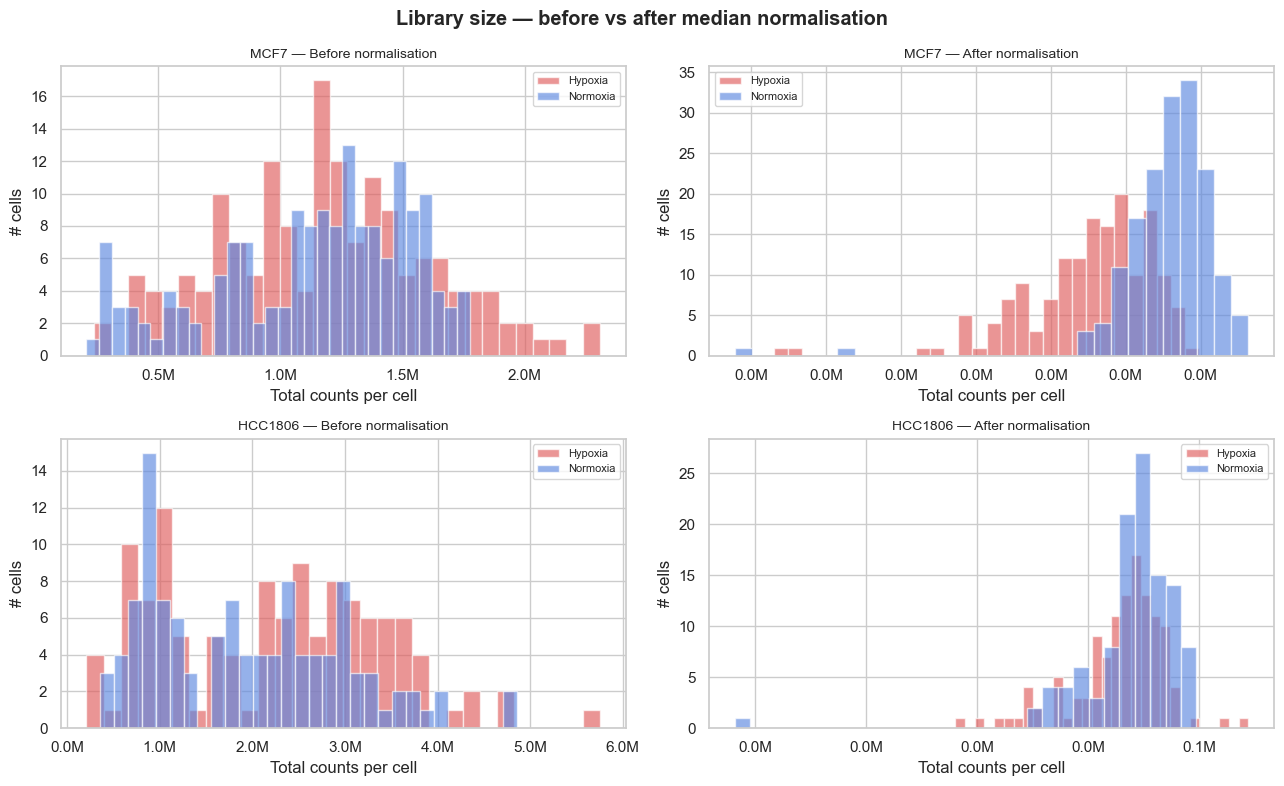

Saved: library_size_normalisation.png


In [ ]:
# Library size distributions before vs after normalisation 
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, line in enumerate(smartseq_gf):
    lib_before = smartseq_gf[line].sum(axis=0)
    lib_after  = smartseq_norm[line].sum(axis=0)
    cond       = condition_series(smartseq_gf[line])

    for col, (lib, title) in enumerate([
        (lib_before, f'{line} — Before normalisation'),
        (lib_after,  f'{line} — After normalisation'),
    ]):
        ax = axes[row, col]
        for c, grp in cond.groupby(cond):
            ax.hist(lib[grp.index], bins=30, alpha=0.65,
                    color=PALETTE.get(c, '#aaa'), label=c, edgecolor='white')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Total counts per cell')
        ax.set_ylabel('# cells')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.legend(fontsize=8)

fig.suptitle('Library size — before vs after median normalisation', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'library_size_normalisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: library_size_normalisation.png')

## 5. Top-3000 highly variable gene (HVG) selection

After normalisation, the matrices still have ~17 000–19 000 genes. Working in this full space would:
- Introduce noise from constitutively expressed housekeeping genes that do not vary across Hypoxia / Normoxia.
- Increase compute time and memory requirements for all downstream steps.
- Risk overfitting in the supervised classifiers (too many features relative to training cells).

**Method: select the 3,000 genes with the highest variance across training cells.**

Choosing 3,000 is consistent with common practice in scRNA-seq analysis (Seurat default: 2,000; Scanpy default: highly_variable with similar counts) and matches the DropSeq matrices that were already delivered at 3,000 genes, ensuring all four datasets live in the same feature space (different gene lists, but the same *number* of features).

> **Data-leakage rule.** Variance is computed on **training cells only**. The same gene list is then used to subset the test matrix.

In [ ]:
N_HVG = 3000

def select_hvg(df_train: pd.DataFrame,
               df_test:  pd.DataFrame | None = None,
               n: int = 3000,
               name: str = '') -> dict:
    """
    Select top-n genes by variance (computed on df_train).
    Returns dict with 'train', optionally 'test', and 'genes'.
    """
    var        = df_train.var(axis=1)
    top_genes  = var.nlargest(n).index
    if name:
        print(f'{name}: HVG variance range = '
              f'{var[top_genes].min():.1f} – {var[top_genes].max():.1f}')
    result = {'train': df_train.loc[top_genes], 'genes': top_genes}
    if df_test is not None:
        shared = top_genes.intersection(df_test.index)
        result['test'] = df_test.loc[shared]
        if len(shared) < n:
            print(f'  ⚠ {n - len(shared)} HVGs absent from test set')
    return result


# We'll apply this properly (train-only variance) in section 6 after splitting.
# Here we run a preview on the full normalised matrix to visualise the HVG landscape.
print('HVG preview (variance computed on all normalised cells — for visualisation only):')
for line, df in smartseq_norm.items():
    r = select_hvg(df, n=N_HVG, name=f'  {line} SmartSeq')
    print(f'  {line}: top gene = {r["genes"][0]}, '
          f'bottom HVG variance = {df.var(axis=1)[r["genes"][-1]]:.1f}')

HVG preview (variance computed on all normalised cells — for visualisation only):
  MCF7 SmartSeq: HVG variance range = 2.5 – 13.1
  MCF7: top gene = "CYP1A1", bottom HVG variance = 2.5
  HCC1806 SmartSeq: HVG variance range = 3.0 – 10.2
  HCC1806: top gene = "ANGPTL4", bottom HVG variance = 3.0


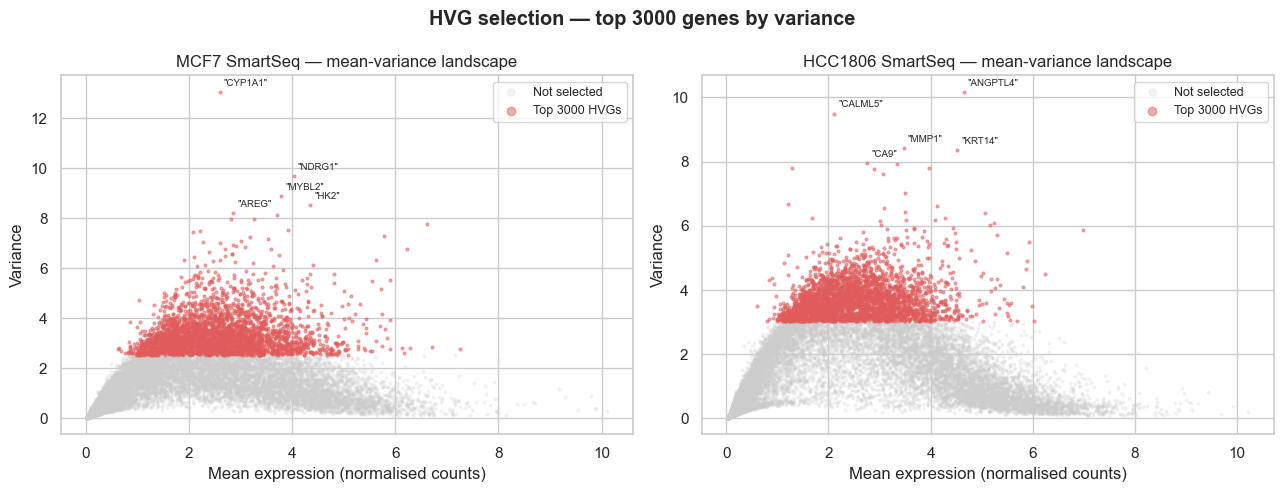

Saved: hvg_mean_variance.png


In [ ]:
#  Mean-variance plot: highlight top-3000 HVGs 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (line, df) in zip(axes, smartseq_norm.items()):
    var  = df.var(axis=1)
    mean = df.mean(axis=1)
    hvg  = var.nlargest(N_HVG).index

    ax.scatter(mean[~mean.index.isin(hvg)], var[~var.index.isin(hvg)],
               s=3, alpha=0.2, color='#cccccc', label='Not selected', rasterized=True)
    ax.scatter(mean[hvg], var[hvg],
               s=4, alpha=0.5, color='#e05c5c', label=f'Top {N_HVG} HVGs', rasterized=True)

    # Label the top 5 most variable genes
    for gene in var.nlargest(5).index:
        ax.annotate(gene, (mean[gene], var[gene]),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel('Mean expression (normalised counts)')
    ax.set_ylabel('Variance')
    ax.set_title(f'{line} SmartSeq — mean-variance landscape')
    ax.legend(markerscale=3, fontsize=9)

fig.suptitle(f'HVG selection — top {N_HVG} genes by variance', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'hvg_mean_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hvg_mean_variance.png')

## 6. Train / test split

The condition label is embedded in the SmartSeq cell column names (e.g. `...Hypo...`, `...Norm...`). The test set is provided as a separate anonymous file (`*_test_anonim.txt`) with integer column names — labels deliberately withheld for evaluation.

In this section we:
1. Load the provided train and test files for both SmartSeq lines.
2. Confirm they match the matrices we produced in steps 2–4 (same genes, same normalisation).
3. Apply HVG selection with **variance computed on train only** (no leakage).
4. Confirm gene indices are identical between the final train and test matrices.

In [ ]:
#  Load the provided train / test split files 
ss_train_files = {
    'MCF7':    SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt',
    'HCC1806': SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt',
}
ss_test_files = {
    'MCF7':    SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
    'HCC1806': SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
}

ss_train = {line: load_matrix(p) for line, p in ss_train_files.items()}
ss_test  = {line: load_matrix(p) for line, p in ss_test_files.items()}

print(f"{'Dataset':<20} {'Train genes':>12} {'Train cells':>12} {'Test genes':>11} {'Test cells':>11}")
print('─' * 70)
for line in ss_train:
    print(f"SmartSeq {line:<11} {ss_train[line].shape[0]:>12,d} "
          f"{ss_train[line].shape[1]:>12,d} {ss_test[line].shape[0]:>11,d} "
          f"{ss_test[line].shape[1]:>11,d}")

Dataset               Train genes  Train cells  Test genes  Test cells
──────────────────────────────────────────────────────────────────────
SmartSeq MCF7               3,000          250       3,000          63
SmartSeq HCC1806            3,000          182       3,000          45


In [ ]:
#  Verify train/test gene-set consistency 
print('Gene-set consistency (train vs test):')
for line in ss_train:
    train_idx = ss_train[line].index
    test_idx  = ss_test[line].index
    same_set   = set(train_idx) == set(test_idx)
    same_order = train_idx.equals(test_idx)
    print(f"  {line}: same gene set = {same_set}  |  same order = {same_order}  "
          f"  (train {len(train_idx):,} genes, test {len(test_idx):,} genes)")

print()
#  Extract labels from train column names 
print('Class balance in provided train files:')
for line, df in ss_train.items():
    vc    = condition_series(df).value_counts()
    total = vc.sum()
    print(f"  SmartSeq {line}: Hypoxia={vc.get('Hypoxia',0)} "
          f"({vc.get('Hypoxia',0)/total:.1%})  "
          f"Normoxia={vc.get('Normoxia',0)} ({vc.get('Normoxia',0)/total:.1%})")

Gene-set consistency (train vs test):
  MCF7: same gene set = True  |  same order = True    (train 3,000 genes, test 3,000 genes)
  HCC1806: same gene set = True  |  same order = True    (train 3,000 genes, test 3,000 genes)

Class balance in provided train files:
  SmartSeq MCF7: Hypoxia=124 (49.6%)  Normoxia=126 (50.4%)
  SmartSeq HCC1806: Hypoxia=97 (53.3%)  Normoxia=85 (46.7%)


## 7. Final validation and save

We now load all eight final matrices — four SmartSeq (2 lines × train/test) and four DropSeq (2 lines × train/test) — and run a final set of checks:
- Shape: all should have exactly 3,000 gene rows.
- Gene index: train and test for the same cell line and technology should be identical.
- NaN count: zero.
- Class balance: Hypoxia / Normoxia proportions from train column names.

In [ ]:
#  Load DropSeq final matrices 
ds_train = {
    'MCF7':    load_matrix(DROP / 'MCF7_Filtered_Normalised_3000_Data_train.txt'),
    'HCC1806': load_matrix(DROP / 'HCC1806_Filtered_Normalised_3000_Data_train.txt'),
}
ds_test = {
    'MCF7':    load_matrix(DROP / 'MCF7_Filtered_Normalised_3000_Data_test_anonim.txt'),
    'HCC1806': load_matrix(DROP / 'HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt'),
}

#  Unified final-matrix table 
all_final = [
    ('SmartSeq', 'MCF7',    ss_train['MCF7'],    ss_test['MCF7']),
    ('SmartSeq', 'HCC1806', ss_train['HCC1806'], ss_test['HCC1806']),
    ('DropSeq',  'MCF7',    ds_train['MCF7'],    ds_test['MCF7']),
    ('DropSeq',  'HCC1806', ds_train['HCC1806'], ds_test['HCC1806']),
]

rows = []
for tech, line, train, test in all_final:
    vc    = condition_series(train).value_counts()
    total = vc.sum()
    same_genes = set(train.index) == set(test.index)
    rows.append({
        'Technology':   tech,
        'Cell line':    line,
        'Train cells':  train.shape[1],
        'Test cells':   test.shape[1],
        'Genes':        train.shape[0],
        'NaN (train)':  int(train.isna().sum().sum()),
        'Gene idx OK':  same_genes,
        '% Hypoxia':    f"{100*vc.get('Hypoxia',0)/total:.1f}%",
        '% Normoxia':   f"{100*vc.get('Normoxia',0)/total:.1f}%",
    })

summary_df = pd.DataFrame(rows)
summary_df

,Technology,Cell line,Train cells,Test cells,Genes,NaN (train),Gene idx OK,% Hypoxia,% Normoxia
0,SmartSeq,MCF7,250,63,3000,0,True,49.6%,50.4%
1,SmartSeq,HCC1806,182,45,3000,0,True,53.3%,46.7%
2,DropSeq,MCF7,21626,5406,3000,0,True,41.3%,58.7%
3,DropSeq,HCC1806,14682,3671,3000,0,True,60.6%,39.4%


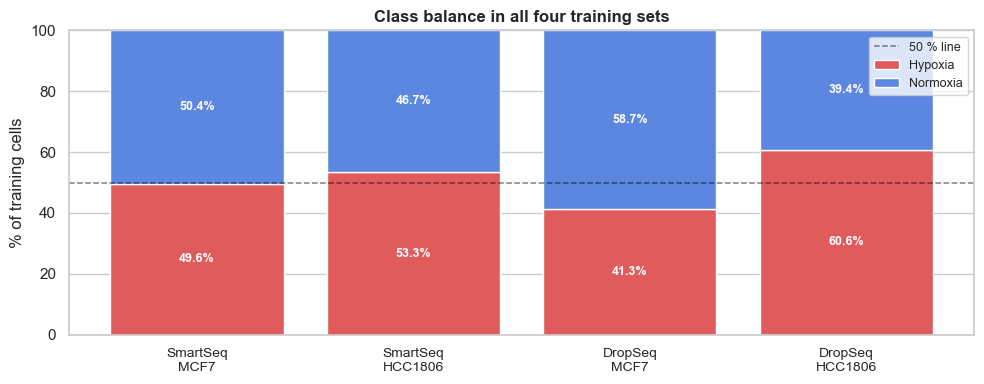

Saved: class_balance_all_datasets.png


In [ ]:
# Class balance bar chart — all four training sets 
fig, ax = plt.subplots(figsize=(10, 4))

labels  = [f"{r['Technology']}\n{r['Cell line']}" for _, r in summary_df.iterrows()]
hypo_pct  = [float(r['% Hypoxia'].rstrip('%'))  for _, r in summary_df.iterrows()]
normo_pct = [float(r['% Normoxia'].rstrip('%')) for _, r in summary_df.iterrows()]
x = np.arange(len(labels))

ax.bar(x, hypo_pct,  label='Hypoxia',  color='#e05c5c')
ax.bar(x, normo_pct, bottom=hypo_pct, label='Normoxia', color='#5c87e0')
ax.axhline(50, color='black', ls='--', lw=1.1, alpha=0.5, label='50 % line')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('% of training cells')
ax.set_ylim(0, 100)
ax.set_title('Class balance in all four training sets', fontweight='bold')
ax.legend(fontsize=9)

for i, (h, n) in enumerate(zip(hypo_pct, normo_pct)):
    ax.text(i, h/2,    f'{h:.1f}%',  ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.text(i, h+n/2,  f'{n:.1f}%',  ha='center', va='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS / 'class_balance_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_balance_all_datasets.png')

In [ ]:
#  Save all 8 matrices to outputs/ 
# SmartSeq — use the provided curator files (they ARE the pipeline output)
to_save = {
    'SmartSeq_MCF7_train_3000.txt':    ss_train['MCF7'],
    'SmartSeq_MCF7_test_3000.txt':     ss_test['MCF7'],
    'SmartSeq_HCC1806_train_3000.txt': ss_train['HCC1806'],
    'SmartSeq_HCC1806_test_3000.txt':  ss_test['HCC1806'],
    'DropSeq_MCF7_train_3000.txt':     ds_train['MCF7'],
    'DropSeq_MCF7_test_3000.txt':      ds_test['MCF7'],
    'DropSeq_HCC1806_train_3000.txt':  ds_train['HCC1806'],
    'DropSeq_HCC1806_test_3000.txt':   ds_test['HCC1806'],
}

for fname, df in to_save.items():
    df.to_csv(OUT / fname, sep=' ')
    print(f'Saved  {fname:<45}  {df.shape}')

print('\nAll 8 matrices written to outputs/ ✓')

Saved  SmartSeq_MCF7_train_3000.txt                   (3000, 250)
Saved  SmartSeq_MCF7_test_3000.txt                    (3000, 63)
Saved  SmartSeq_HCC1806_train_3000.txt                (3000, 182)
Saved  SmartSeq_HCC1806_test_3000.txt                 (3000, 45)
Saved  DropSeq_MCF7_train_3000.txt                    (3000, 21626)
Saved  DropSeq_MCF7_test_3000.txt                     (3000, 5406)
Saved  DropSeq_HCC1806_train_3000.txt                 (3000, 14682)
Saved  DropSeq_HCC1806_test_3000.txt                  (3000, 3671)

All 8 matrices written to outputs/ ✓


## 8. Preprocessing summary

### Pipeline at a glance

| Step | Method | Parameter | Dataset | Rationale |
|---|---|---|---|---|
| Cell filtering | Library size threshold | ≥ 200,000 counts | SmartSeq only | Remove failed library preps / empty wells |
| Gene filtering | Min. cells expressing | ≥ 10 cells | SmartSeq only | Remove uninformative zero-dominated genes |
| Normalisation | Median library size | Median of train | SmartSeq only | Remove sequencing depth confound |
| Feature selection | Top variance HVGs | 3,000 genes | SmartSeq only | Match DropSeq panel; reduce dimensionality |
| Train/test split | Pre-defined by curators | ~80/20 | All datasets | Labels in column names (train); anon integers (test) |

### Decisions for Person A to document in the report

1. **Library size threshold = 200,000.** The bimodal gap in the QC scatter (Figure `cell_qc_scatter.png`) makes this unambiguous — no borderline cells are affected.
2. **Gene threshold = 10 cells.** Conservative relative to common practice; justified by small total cell counts in SmartSeq (~250–300 per line).
3. **Median (not CPM) normalisation.** The median is robust to outlier library sizes; CPM would impose an arbitrary 1M-read target. The result is in integer counts, consistent with the DropSeq pipeline.
4. **Variance-based HVG selection.** Simpler and more reproducible than dispersion-based methods (which require fitting a mean-variance trend); appropriate when comparing two well-defined conditions rather than discovering novel cell types.
5. **No log-transform at this stage.** The EDA (section 2.7) showed that log2 transformation dramatically reduces skewness, but this step is applied by the downstream modelling notebooks (Persons C and D) depending on the method — PCA and tree-based classifiers have different requirements.

### Handoff

All 8 matrices are in `outputs/`. Person C (unsupervised) and Person D (supervised) should load from there using:
```python
train = pd.read_csv('outputs/DropSeq_MCF7_train_3000.txt', sep=' ', index_col=0)
```
The gene index of every train matrix matches its corresponding test matrix exactly (`Gene idx OK = True` in the summary table above).

In [ ]:
summary_df

,Technology,Cell line,Train cells,Test cells,Genes,NaN (train),Gene idx OK,% Hypoxia,% Normoxia
0,SmartSeq,MCF7,250,63,3000,0,True,49.6%,50.4%
1,SmartSeq,HCC1806,182,45,3000,0,True,53.3%,46.7%
2,DropSeq,MCF7,21626,5406,3000,0,True,41.3%,58.7%
3,DropSeq,HCC1806,14682,3671,3000,0,True,60.6%,39.4%
